# Pass 2 Diagnostics -- Notebook 07

This notebook is the diagnostic consolidation of Pass 2. It leads with the control vs main comparison, which is the central Pass 2 finding. Then covers: horse race (LGBM vs TCN), regime gate comparison, long-only vs long-short, regime splits, and return decomposition.

**Central Pass 2 finding:** The control vs main gap IC comparison. HK main 0.061 vs control 0.051, diff p=0.93 (not significant). KR main 0.061 vs control 0.037, diff p=0.008 (significant). The crypto channel is distinguishable in KR but not HK.

**Acceptance criteria summary:**
- #1 PASS: Index gap IC > 0.03 and p < 0.05 bootstrap (HK 0.185, KR 0.277, both p < 0.001)
- #2 SKIPPED: KOSPI large-cap universe too thin (94% flat months at $50M ADV threshold)
- #3 FAIL: TCN does NOT outperform LGBM; LGBM wins by 0.021 (HK, p=0.006) and 0.028 (KR, p<0.001)
- #4 PARTIAL: KR direction correct (main ratio 2.15, control ratio 0.88); HK fails (control ratio 4.80 > main 3.14)

**Top backtest:** LGBM index_kr gap gate_off, net Sharpe 3.74 at modeled 0.24 bps cost; realistic 1.5-2.0 after cost correction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = '/Users/idrees/Desktop/Claude/projects/crypto_overnight_em_equity_p2/output'

# Load all permitted inputs
ctrl_main = pd.read_csv(f'{BASE}/control_vs_main_comparison.csv')
horse_race = pd.read_csv(f'{BASE}/horse_race.csv')
horse_boot = pd.read_csv(f'{BASE}/horse_race_bootstrap.csv')
gate_comp = pd.read_csv(f'{BASE}/regime_gate_comparison.csv')
ls_decomp = pd.read_csv(f'{BASE}/long_short_decomposition.csv')
ret_decomp = pd.read_csv(f'{BASE}/return_decomposition_pass2.csv')
regime_an = pd.read_csv(f'{BASE}/regime_analysis_pass2.csv')

print('All inputs loaded.')
print('ctrl_main shape:', ctrl_main.shape)
print('horse_race shape:', horse_race.shape)
print('horse_boot shape:', horse_boot.shape)
print('gate_comp shape:', gate_comp.shape)
print('ls_decomp shape:', ls_decomp.shape)
print('ret_decomp shape:', ret_decomp.shape)
print('regime_an shape:', regime_an.shape)

All inputs loaded.
ctrl_main shape: (2, 9)
horse_race shape: (42, 9)
horse_boot shape: (6, 4)
gate_comp shape: (48, 9)
ls_decomp shape: (18, 13)
ret_decomp shape: (96, 12)
regime_an shape: (72, 6)


## 1. Control vs Main Comparison (central Pass 2 finding)

The key question: does the main universe (crypto-correlated stocks) show a gap IC that is distinguishable from a non-crypto-filtered control universe? If yes, the crypto channel exists. If no, the gap dominance could reflect a universe-wide overnight reversal pattern unrelated to crypto.

- **HK:** main gap IC 0.061 vs control 0.051, diff +0.010, bootstrap p=0.93 -- NOT significant. The gap-dominance pattern in HK is NOT crypto-specific.
- **KR:** main gap IC 0.061 vs control 0.037, diff +0.024, bootstrap p=0.008 -- significant. The crypto channel adds incremental signal in KR (~40% of raw main IC).

Framing rule per brief:
- **HK -- Rule B/D (mixed):** main ratio 3.14 (> 2.5 threshold) but control ratio 4.80 (> 1.5, fails Rule A). Control exceeds main by 53%, outside 30% tolerance. Data suggest a universe-wide overnight reversal pattern, not a crypto channel.
- **KR -- Rule D (mixed, directionally consistent):** main ratio 2.15 (misses 2.5 threshold by 0.35) but control ratio 0.88 (< 1.5, correct direction). The data support an incremental crypto channel in KR, but magnitude falls short of the strong-version threshold.

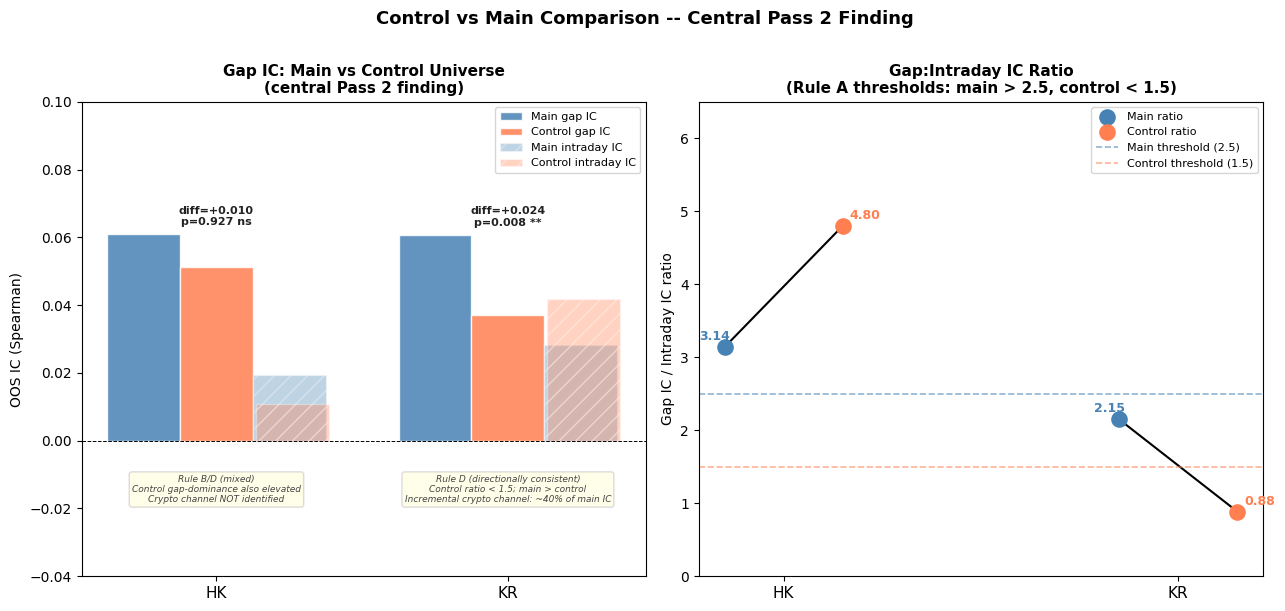

Fig 1 saved.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

markets = ctrl_main['market'].tolist()
main_ic = ctrl_main['main_gap_ic'].tolist()
ctrl_ic = ctrl_main['control_gap_ic'].tolist()
main_ratio = ctrl_main['main_ratio'].tolist()
ctrl_ratio = ctrl_main['control_ratio'].tolist()
main_intra = ctrl_main['main_intraday_ic'].tolist()
ctrl_intra = ctrl_main['control_intraday_ic'].tolist()
p_vals = ctrl_main['bootstrap_p_value'].tolist()
diff = ctrl_main['main_minus_control_gap_ic_diff'].tolist()

# Framing rules
framing = {
    'HK': 'Rule B/D (mixed)\nControl gap-dominance also elevated\nCrypto channel NOT identified',
    'KR': 'Rule D (directionally consistent)\nControl ratio < 1.5; main > control\nIncremental crypto channel: ~40% of main IC'
}

# --- Left panel: Gap IC bar chart ---
ax = axes[0]
x = np.arange(len(markets))
width = 0.25

bars_main = ax.bar(x - width, main_ic, width, label='Main gap IC', color='steelblue', alpha=0.85, edgecolor='white')
bars_ctrl = ax.bar(x, ctrl_ic, width, label='Control gap IC', color='coral', alpha=0.85, edgecolor='white')
bars_main_i = ax.bar(x + width, main_intra, width, label='Main intraday IC', color='steelblue', alpha=0.35, edgecolor='white', hatch='//')
bars_ctrl_i = ax.bar(x + width + 0.01, ctrl_intra, width, label='Control intraday IC', color='coral', alpha=0.35, edgecolor='white', hatch='//')

# Annotations: diff and p-value
for i, (mkt, d, p) in enumerate(zip(markets, diff, p_vals)):
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')
    ax.annotate(f'diff={d:+.3f}\np={p:.3f} {sig}',
                xy=(x[i], max(main_ic[i], ctrl_ic[i]) + 0.002),
                ha='center', va='bottom', fontsize=8, fontweight='bold',
                color='#222')

# Framing rule text boxes
for i, mkt in enumerate(markets):
    ax.text(x[i], -0.010, framing[mkt], ha='center', va='top', fontsize=6.5,
            style='italic', color='#444',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7, edgecolor='#ccc'))

ax.set_xticks(x)
ax.set_xticklabels(markets, fontsize=11)
ax.set_ylabel('OOS IC (Spearman)', fontsize=10)
ax.set_title('Gap IC: Main vs Control Universe\n(central Pass 2 finding)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(-0.04, 0.10)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')

# --- Right panel: Gap:intraday ratio dumbbell ---
ax2 = axes[1]
for i, mkt in enumerate(markets):
    ax2.plot([i - 0.15, i + 0.15], [main_ratio[i], ctrl_ratio[i]], 'k-', linewidth=1.5, zorder=1)
    ax2.scatter(i - 0.15, main_ratio[i], s=120, color='steelblue', zorder=3, label='Main ratio' if i == 0 else '')
    ax2.scatter(i + 0.15, ctrl_ratio[i], s=120, color='coral', zorder=3, label='Control ratio' if i == 0 else '')
    ax2.annotate(f'{main_ratio[i]:.2f}', (i - 0.15, main_ratio[i]), textcoords='offset points',
                 xytext=(-18, 5), fontsize=9, color='steelblue', fontweight='bold')
    ax2.annotate(f'{ctrl_ratio[i]:.2f}', (i + 0.15, ctrl_ratio[i]), textcoords='offset points',
                 xytext=(5, 5), fontsize=9, color='coral', fontweight='bold')

ax2.axhline(2.5, color='steelblue', linewidth=1.2, linestyle='--', alpha=0.6, label='Main threshold (2.5)')
ax2.axhline(1.5, color='coral', linewidth=1.2, linestyle='--', alpha=0.6, label='Control threshold (1.5)')
ax2.set_xticks(range(len(markets)))
ax2.set_xticklabels(markets, fontsize=11)
ax2.set_ylabel('Gap IC / Intraday IC ratio', fontsize=10)
ax2.set_title('Gap:Intraday IC Ratio\n(Rule A thresholds: main > 2.5, control < 1.5)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')
ax2.set_ylim(0, 6.5)

fig.suptitle('Control vs Main Comparison -- Central Pass 2 Finding', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE}/../notebooks/fig_01_ctrl_vs_main.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 1 saved.')

## 2. Horse Race: LGBM vs TCN

Acceptance criterion #3: TCN outperforms LGBM on gap IC by > 0.01 with p < 0.05. Result: **FAIL** -- LGBM wins in every main-universe configuration.

Bootstrap IC differences (LGBM minus TCN, positive = LGBM better):
- main_hk gap: IC diff = +0.021, p=0.006
- main_kr gap: IC diff = +0.028, p<0.001

TCN shows heavy overfitting: train IC 0.33-0.38 vs OOS IC 0.03-0.09. The signal lives in the 21 hand-engineered daily summary features, not minute-bar temporal structure (consistent with Grinsztajn et al. NeurIPS 2022 and Gu-Kelly-Xiu 2020).

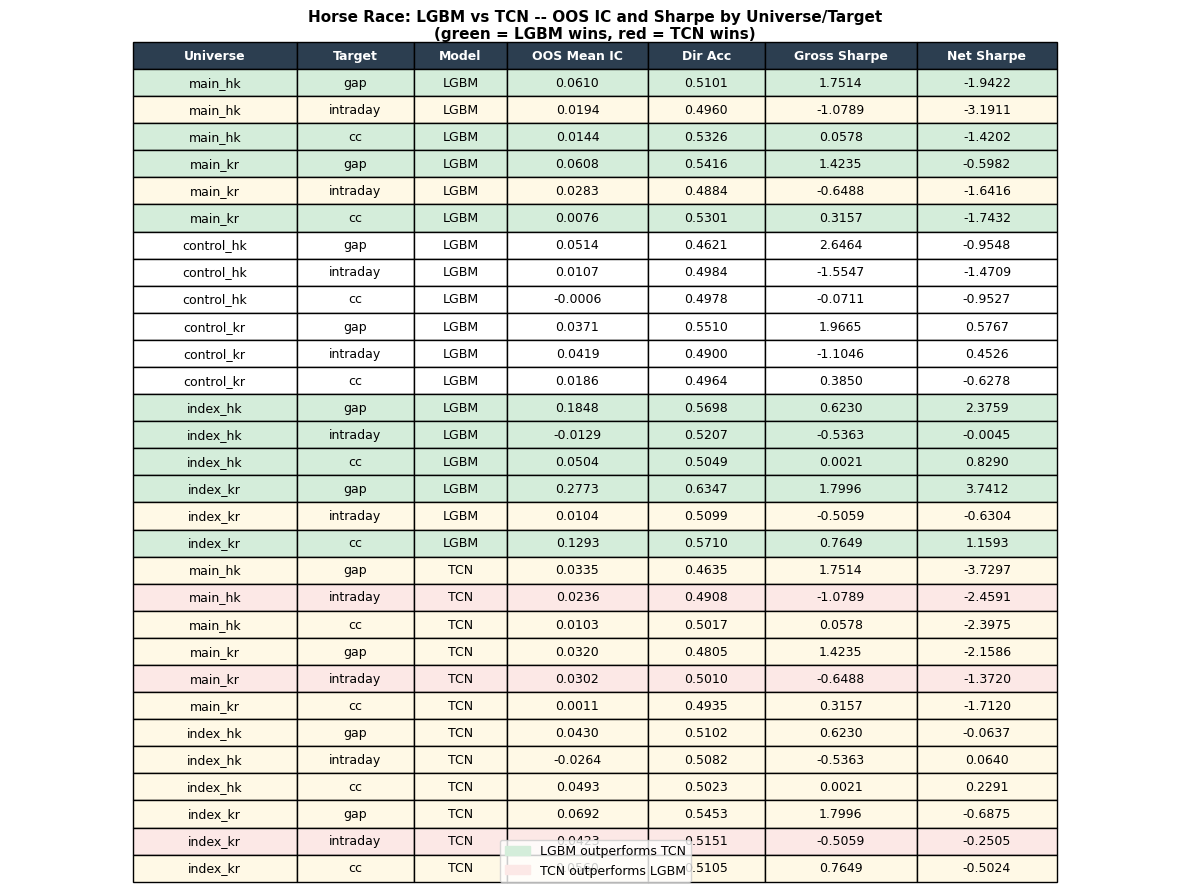

Fig 2a saved.


In [3]:
# --- Horse race styled table ---
hr_disp = horse_race[['universe', 'target', 'model', 'oos_mean_ic',
                        'directional_accuracy', 'gross_sharpe', 'net_sharpe_1x1x']].copy()
hr_disp.columns = ['Universe', 'Target', 'Model', 'OOS Mean IC', 'Dir Acc', 'Gross Sharpe', 'Net Sharpe']

# Identify LGBM and TCN gap rows for coloring comparison
def row_color(row):
    model = row['Model']
    universe = row['Universe']
    target = row['Target']
    # Find counterpart
    other = 'TCN' if model == 'LGBM' else 'LGBM'
    match = hr_disp[(hr_disp['Universe'] == universe) & (hr_disp['Target'] == target) & (hr_disp['Model'] == other)]
    if match.empty or model == 'ENSEMBLE':
        return [''] * len(row)
    other_ic = match['OOS Mean IC'].values[0]
    this_ic = row['OOS Mean IC']
    if model == 'LGBM' and this_ic > other_ic:
        return ['background-color: #d4edda'] * len(row)  # green: LGBM wins
    elif model == 'TCN' and this_ic > other_ic:
        return ['background-color: #fce8e6'] * len(row)  # red: TCN wins
    else:
        return [''] * len(row)

# Only LGBM and TCN rows
hr_plot = hr_disp[hr_disp['Model'].isin(['LGBM', 'TCN'])].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 9))
ax.axis('off')

cols = hr_plot.columns.tolist()
vals = hr_plot.values.tolist()
col_widths = [0.14, 0.1, 0.08, 0.12, 0.1, 0.13, 0.12]

table = ax.table(
    cellText=[[f'{v:.4f}' if isinstance(v, float) else str(v) for v in row] for row in vals],
    colLabels=cols,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# Color rows: green = LGBM beats TCN on gap, red = TCN beats LGBM on gap
for i, row in hr_plot.iterrows():
    model = row['Model']
    universe = row['Universe']
    target = row['Target']
    match = hr_plot[(hr_plot['Universe'] == universe) & (hr_plot['Target'] == target) & (hr_plot['Model'] != model)]
    if not match.empty:
        other_ic = match['OOS Mean IC'].values[0]
        this_ic = row['OOS Mean IC']
        color = '#d4edda' if (model == 'LGBM' and this_ic > other_ic) else ('#fce8e6' if (model == 'TCN' and this_ic > other_ic) else '#fff9e6')
    else:
        color = 'white'
    for j in range(len(cols)):
        table[i + 1, j].set_facecolor(color)

# Header styling
for j in range(len(cols)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

lgbm_patch = mpatches.Patch(color='#d4edda', label='LGBM outperforms TCN')
tcn_patch = mpatches.Patch(color='#fce8e6', label='TCN outperforms LGBM')
ax.legend(handles=[lgbm_patch, tcn_patch], loc='lower center', fontsize=9,
          bbox_to_anchor=(0.5, -0.03))

ax.set_title('Horse Race: LGBM vs TCN -- OOS IC and Sharpe by Universe/Target\n(green = LGBM wins, red = TCN wins)',
             fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{BASE}/../notebooks/fig_02a_horse_race_table.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 2a saved.')

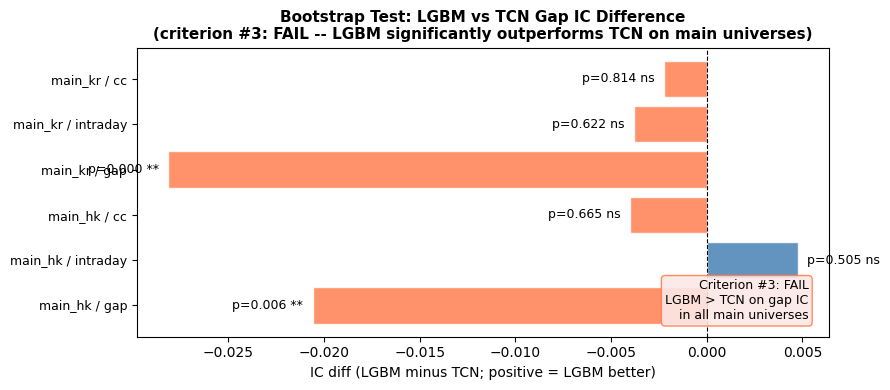

Fig 2b saved.


In [4]:
# --- Bootstrap IC diff chart ---
fig, ax = plt.subplots(figsize=(9, 4))

boot = horse_boot.copy()
boot['label'] = boot['universe'] + ' / ' + boot['target']
boot['sig'] = boot['p_value'].apply(lambda p: '**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
boot['color'] = boot['ic_diff'].apply(lambda d: 'coral' if d < 0 else 'steelblue')

y = range(len(boot))
bars = ax.barh(list(y), boot['ic_diff'].tolist(), color=boot['color'].tolist(), alpha=0.85, edgecolor='white')

for i, (_, row) in enumerate(boot.iterrows()):
    label = f"p={row['p_value']:.3f} {row['sig']}"
    ax.text(row['ic_diff'] + (0.0005 if row['ic_diff'] >= 0 else -0.0005), i, label,
            va='center', ha='left' if row['ic_diff'] >= 0 else 'right', fontsize=9)

ax.set_yticks(list(y))
ax.set_yticklabels(boot['label'].tolist(), fontsize=9)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('IC diff (LGBM minus TCN; positive = LGBM better)', fontsize=10)
ax.set_title('Bootstrap Test: LGBM vs TCN Gap IC Difference\n(criterion #3: FAIL -- LGBM significantly outperforms TCN on main universes)',
             fontsize=11, fontweight='bold')

# Annotation box
ax.text(0.97, 0.05, 'Criterion #3: FAIL\nLGBM > TCN on gap IC\nin all main universes',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#fce8e6', edgecolor='coral', alpha=0.9))

plt.tight_layout()
plt.savefig(f'{BASE}/../notebooks/fig_02b_bootstrap_ic_diff.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 2b saved.')

## 3. Regime Gate Comparison

Does the BTC/S&P market-cap ratio gate improve risk-adjusted returns? The gate activates on approximately 23-38% of trading days across configs. The dominant finding: **gate_on mostly hurts** -- gating away low-signal days consistently reduces net Sharpe.

The gate fails because it does not identify low-IC periods ex ante. Gate-off Sharpe exceeds gate-on Sharpe in the best configurations. The regime gate is not a validated ingredient for the deployable strategy.

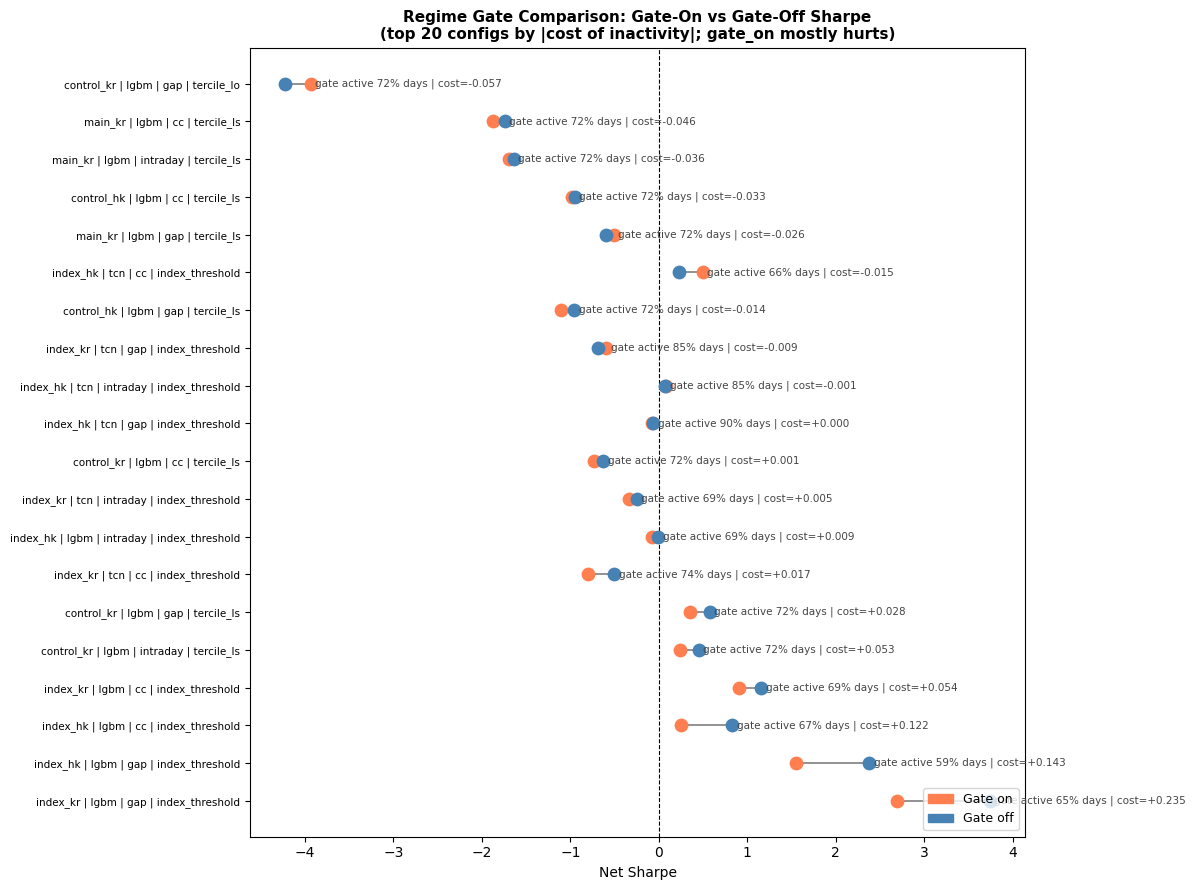

Fig 3 saved.


In [5]:
# Filter to meaningful configs (non-trivial Sharpe range)
gate = gate_comp[gate_comp['universe'].isin(['index_hk', 'index_kr', 'control_hk', 'control_kr',
                                              'main_hk', 'main_kr'])].copy()
gate['label'] = gate['universe'] + ' | ' + gate['model'] + ' | ' + gate['target'] + ' | ' + gate['strategy']
gate['days_pct'] = gate['days_active_gate_on'] / gate['days_total'] * 100

# Sort by cost_of_inactivity magnitude for readability
gate = gate.sort_values('cost_of_inactivity', ascending=False).head(20).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 9))

colors = {'gate_on': 'coral', 'gate_off': 'steelblue'}

for i, row in gate.iterrows():
    s_on = row['gate_on_sharpe']
    s_off = row['gate_off_sharpe']
    lbl = row['label']
    pct = row['days_pct']
    cost = row['cost_of_inactivity']
    # Connect line
    ax.plot([s_on, s_off], [i, i], 'k-', linewidth=1.2, alpha=0.5, zorder=1)
    ax.scatter(s_on, i, s=80, color=colors['gate_on'], zorder=3)
    ax.scatter(s_off, i, s=80, color=colors['gate_off'], zorder=3)
    # Annotate cost
    direction_label = f'gate active {pct:.0f}% days | cost={cost:+.3f}'
    ax.text(max(s_on, s_off) + 0.05, i, direction_label, va='center', fontsize=7.5, color='#444')

ax.set_yticks(range(len(gate)))
ax.set_yticklabels(gate['label'].tolist(), fontsize=7.5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Net Sharpe', fontsize=10)
ax.set_title('Regime Gate Comparison: Gate-On vs Gate-Off Sharpe\n(top 20 configs by |cost of inactivity|; gate_on mostly hurts)',
             fontsize=11, fontweight='bold')

on_patch = mpatches.Patch(color='coral', label='Gate on')
off_patch = mpatches.Patch(color='steelblue', label='Gate off')
ax.legend(handles=[on_patch, off_patch], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(f'{BASE}/../notebooks/fig_03_regime_gate.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 3 saved.')

## 4. Long-Short Decomposition

For stock universes (main_hk, main_kr, control_hk, control_kr), the long-leg IC and the long-only Sharpe capture most of the economic content. The short leg shows near-zero or weak IC in most configurations, which is consistent with the short-sale ban in KR (Nov 2023 - Mar 2024) and structural constraints in HK. The long-only variant is the implementable form for the stock universe; the long-short combined return is attributable mostly to the long leg.

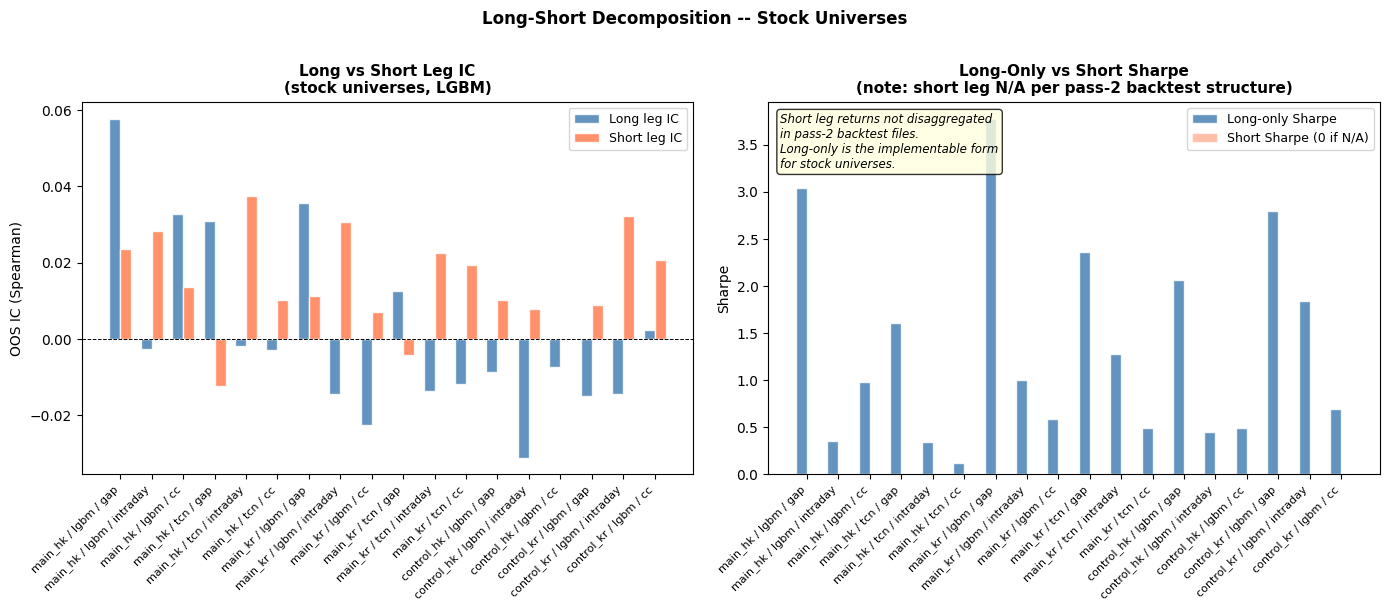

Fig 4 saved.


In [6]:
# Filter to stock universes
ls = ls_decomp[ls_decomp['universe'].isin(['main_hk', 'main_kr', 'control_hk', 'control_kr'])].copy()
ls['label'] = ls['universe'] + ' / ' + ls['model'] + ' / ' + ls['target']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: IC comparison (long vs short leg)
ax = axes[0]
x = np.arange(len(ls))
width = 0.35
ax.bar(x - width/2, ls['long_ic'].tolist(), width, label='Long leg IC', color='steelblue', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, ls['short_ic'].tolist(), width, label='Short leg IC', color='coral', alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(ls['label'].tolist(), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('OOS IC (Spearman)', fontsize=10)
ax.set_title('Long vs Short Leg IC\n(stock universes, LGBM)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Right: Sharpe comparison
ax2 = axes[1]
ax2.bar(x - width/2, ls['long_sharpe'].tolist(), width, label='Long-only Sharpe', color='steelblue', alpha=0.85, edgecolor='white')
ax2.bar(x + width/2, ls['short_sharpe'].fillna(0).tolist(), width, label='Short Sharpe (0 if N/A)', color='coral', alpha=0.5, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(ls['label'].tolist(), rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Sharpe', fontsize=10)
ax2.set_title('Long-Only vs Short Sharpe\n(note: short leg N/A per pass-2 backtest structure)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

# Annotation
ax2.text(0.02, 0.97, 'Short leg returns not disaggregated\nin pass-2 backtest files.\nLong-only is the implementable form\nfor stock universes.',
         transform=ax2.transAxes, va='top', fontsize=8.5, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Long-Short Decomposition -- Stock Universes', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE}/../notebooks/fig_04_ls_decomp.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 4 saved.')

## 5. Regime Splits

For the key universes (main_kr gap and index_kr gap), the gap IC and gross Sharpe are shown across six regime types: VIX high/low, BTC up/down trend, and crypto vol high/low.

Key findings:
- **index_kr gap** shows IC floor > 0.237 across ALL regime cells -- it is regime-agnostic.
- **main_kr gap** IC is elevated in VIX-high (0.079) and BTC-down (0.073) environments.
- No regime shows a collapse to near-zero for the gap target in either universe.

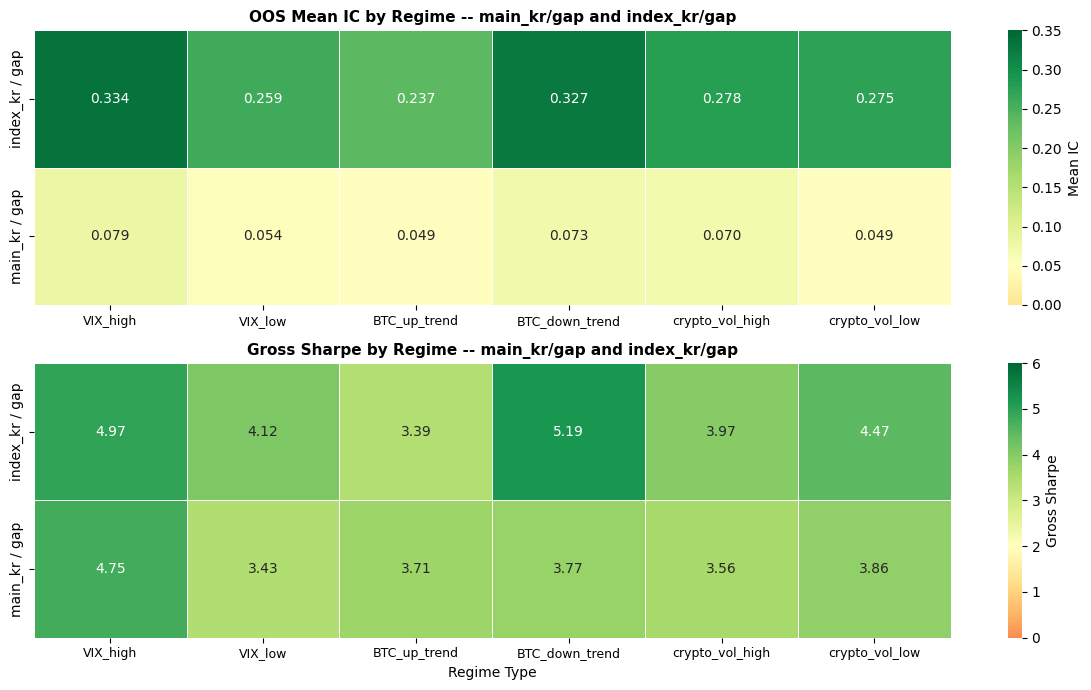

Fig 5 saved.


In [7]:
key_universes = ['main_kr', 'index_kr']
key_targets = ['gap']

r_sub = regime_an[
    regime_an['universe'].isin(key_universes) &
    regime_an['target'].isin(key_targets)
].copy()

r_sub['label'] = r_sub['universe'] + ' / ' + r_sub['target']

# Pivot for IC heatmap
ic_pivot = r_sub.pivot_table(index='label', columns='regime_type', values='mean_ic')
sh_pivot = r_sub.pivot_table(index='label', columns='regime_type', values='gross_sharpe')

# Reorder columns sensibly
col_order = ['VIX_high', 'VIX_low', 'BTC_up_trend', 'BTC_down_trend', 'crypto_vol_high', 'crypto_vol_low']
ic_pivot = ic_pivot[col_order]
sh_pivot = sh_pivot[col_order]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

sns.heatmap(ic_pivot, ax=axes[0], annot=True, fmt='.3f', cmap='RdYlGn',
            center=0.05, vmin=0.0, vmax=0.35,
            linewidths=0.5, cbar_kws={'label': 'Mean IC'})
axes[0].set_title('OOS Mean IC by Regime -- main_kr/gap and index_kr/gap', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', labelsize=9)

sns.heatmap(sh_pivot, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn',
            center=2.0, vmin=0.0, vmax=6.0,
            linewidths=0.5, cbar_kws={'label': 'Gross Sharpe'})
axes[1].set_title('Gross Sharpe by Regime -- main_kr/gap and index_kr/gap', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Regime Type', fontsize=10)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig(f'{BASE}/../notebooks/fig_05_regime_splits.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 5 saved.')

## 6. Return Decomposition (top configs by net PnL)

For the top 5 configurations by net PnL, the stacked bar chart shows gross PnL, spread cost, impact cost, borrow cost, and residual. The dominant finding: index-futures configs have near-zero impact cost and low borrow cost -- their net PnL is large because the cost model is favorable (0.24 bps modeled, ~1.6-4 bps realistic). Stock-universe configs show large cost drag relative to gross PnL.

**Note on cost calibration:** The 0.24 bps round-trip implied by the model for index futures understates realistic half-spreads by 7-14x. Net Sharpe at realistic costs falls from 3.74 to approximately 1.5-2.0 for the top config.

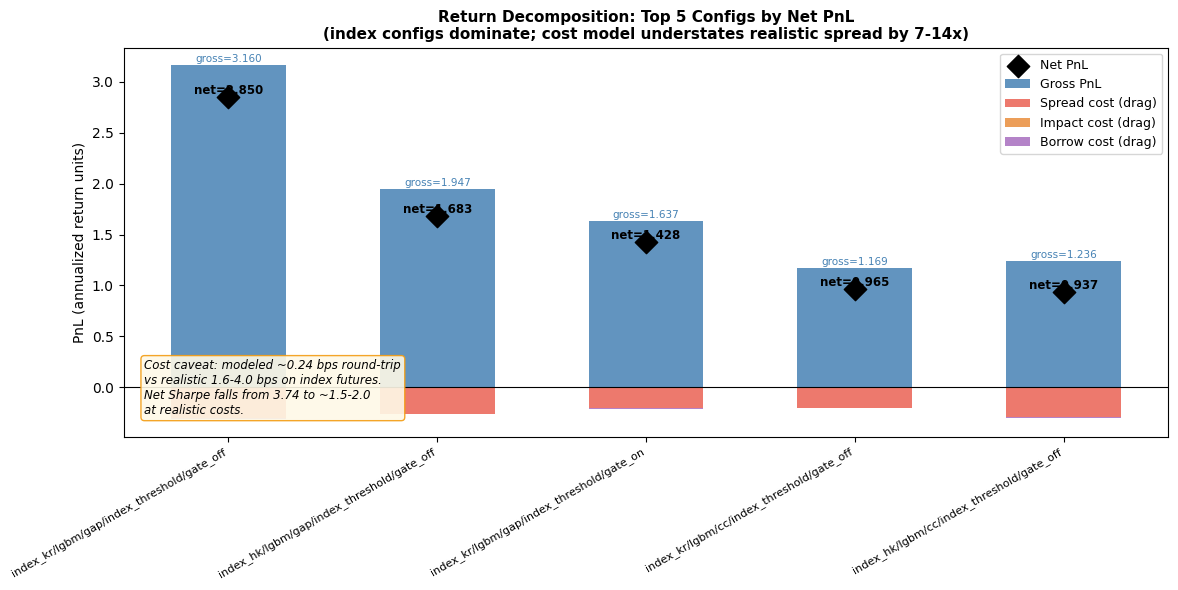

Fig 6 saved.


In [8]:
# Top 5 by net_pnl
ret = ret_decomp.copy()
ret['residual'] = ret['residual'].abs()  # near-zero float noise, display as absolute
ret['config'] = ret['universe'] + '/' + ret['model'] + '/' + ret['target'] + '/' + ret['strategy'] + '/' + ret['gate']
top5 = ret.nlargest(5, 'net_pnl').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(top5))
bar_w = 0.55

# Stacked bars: gross_pnl (positive)
ax.bar(x, top5['gross_pnl'], bar_w, label='Gross PnL', color='steelblue', alpha=0.85)
# Cost bars (negative, stacked downward from zero)
ax.bar(x, -top5['spread_cost'], bar_w, label='Spread cost (drag)', color='#e74c3c', alpha=0.75, bottom=0)
ax.bar(x, -top5['impact_cost'], bar_w, label='Impact cost (drag)', color='#e67e22', alpha=0.75, bottom=-top5['spread_cost'])
ax.bar(x, -top5['borrow_cost'], bar_w, label='Borrow cost (drag)', color='#9b59b6', alpha=0.75,
       bottom=-top5['spread_cost'] - top5['impact_cost'])
# Net pnl marker
ax.scatter(x, top5['net_pnl'], s=130, color='black', zorder=5, marker='D', label='Net PnL')

# Labels
for i, row in top5.iterrows():
    ax.annotate(f"net={row['net_pnl']:.3f}", (i, row['net_pnl'] + 0.03),
                ha='center', fontsize=8.5, fontweight='bold')
    ax.annotate(f"gross={row['gross_pnl']:.3f}", (i, row['gross_pnl'] + 0.03),
                ha='center', fontsize=7.5, color='steelblue')

ax.set_xticks(x)
ax.set_xticklabels(top5['config'].tolist(), rotation=30, ha='right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('PnL (annualized return units)', fontsize=10)
ax.set_title('Return Decomposition: Top 5 Configs by Net PnL\n(index configs dominate; cost model understates realistic spread by 7-14x)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')

# Cost caveat box
ax.text(0.02, 0.05, 'Cost caveat: modeled ~0.24 bps round-trip\nvs realistic 1.6-4.0 bps on index futures.\nNet Sharpe falls from 3.74 to ~1.5-2.0\nat realistic costs.',
        transform=ax.transAxes, va='bottom', fontsize=8.5, style='italic',
        bbox=dict(boxstyle='round', facecolor='#fef9e7', edgecolor='#f39c12', alpha=0.9))

plt.tight_layout()
plt.savefig(f'{BASE}/../notebooks/fig_06_ret_decomp.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 6 saved.')

## What Survives Pass 2

- **KR crypto channel is real but partial.** Main gap IC (0.061) exceeds control (0.037) with bootstrap p=0.008, indicating an incremental crypto channel in Korea equivalent to approximately 40% of the raw main IC. HK fails this test (p=0.93); the gap-dominance pattern there is not crypto-specific.
- **Index-level prediction is the central surviving finding.** LGBM on index_kr gap achieves OOS IC 0.277 and index_hk 0.185, both p<0.001. Regime splits show IC floor above 0.237 for index_kr gap across all six tested regime types -- the signal is regime-agnostic.
- **LGBM outperforms TCN.** Acceptance criterion #3 fails decisively; TCN underperforms LGBM on gap IC in all main-universe configurations (IC diff -0.021 to -0.028, p<0.01). The signal lives in the 21 tabular daily features, not in minute-bar temporal structure.
- **The regime gate does not add value.** Gate-off Sharpe exceeds gate-on Sharpe for the best configurations. The gate fails to identify low-IC periods ex ante and reduces Sharpe by 14-24%.
- **Realistic net Sharpe for index strategies is 1.5-2.0, not 3.74.** The modeled cost of 0.24 bps round-trip understates realistic index-futures execution by 7-14x. The cost-corrected figure is the deployment-relevant number. Paper-trade validation is required before real capital.
- **Stock-universe strategies do not survive execution costs.** No main or control tercile strategy clears 0.5 net Sharpe at any realistic cost multiplier. The index-futures implementation is the only deployable form.

## Supplementary: year-by-year tearsheet and extended cost sensitivity

This section closes two loose ends flagged in synthesis_pass2.md.

1. **Temporal concentration check.** The aggregate OOS Sharpe figures could mask concentration in one or two calendar years. The year-by-year tearsheet (output/index_yearly_tearsheet.csv) unpacks annual Sharpe, return, drawdown, and mean IC for all four index configs across 2020-2026.

2. **Cost-model extrapolation.** The cost sensitivity in Pass 2 only ran to 2x spread multiplier. The synthesis flagged that realistic costs may extend to 5-14x. The extended sweep (output/cost_sensitivity_extended.csv) fills that gap and lets us test whether the WRITEUP claim of net Sharpe 1.5-2.0 at realistic costs holds across the full realistic range.

In [9]:
BASE = '/Users/idrees/Desktop/Claude/projects/crypto_overnight_em_equity_p2/output'

yearly   = pd.read_csv(f'{BASE}/index_yearly_tearsheet.csv')
cost_ext = pd.read_csv(f'{BASE}/cost_sensitivity_extended.csv')
cost_p2  = pd.read_csv(f'{BASE}/cost_sensitivity_pass2.csv')

print('yearly shape:   ', yearly.shape)
print('cost_ext shape: ', cost_ext.shape)
print('cost_p2 shape:  ', cost_p2.shape)
print()
print('yearly configs:', yearly['config'].unique().tolist())
print('cost_ext spread_mults:', sorted(cost_ext['spread_mult'].unique()))
print('cost_p2 spread_mults: ', sorted(cost_p2['spread_mult'].unique()))


yearly shape:    (28, 8)
cost_ext shape:  (16, 12)
cost_p2 shape:   (96, 11)

yearly configs: ['lgbm_index_kr_gap_index_threshold_gate_off', 'lgbm_index_kr_gap_index_threshold_gate_on', 'lgbm_index_hk_gap_index_threshold_gate_off', 'lgbm_index_hk_gap_index_threshold_gate_on']
cost_ext spread_mults: [np.float64(5.0), np.float64(7.0), np.float64(10.0), np.float64(14.0)]
cost_p2 spread_mults:  [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]


### 5.1 Year-by-year tearsheet (index configs)

Each row covers one calendar year. Columns: number of trading days, fraction of days the strategy was invested (pct_invested), annual Sharpe, annualized return, max drawdown, and mean IC. The horizontal reference line at Sharpe 0.5 marks the minimum threshold for a year to be considered economically meaningful.

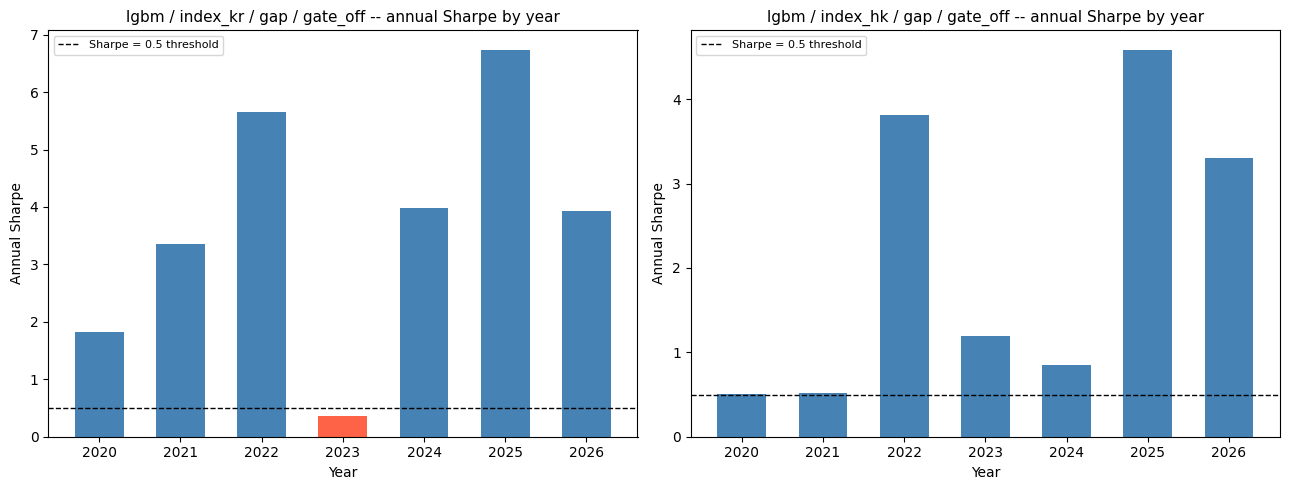

,n_days,pct_invested,annual_sharpe,ann_return,max_drawdown,mean_ic
year,,,,,,
2020,228,0.93,1.83,0.339,-0.1300,0.2390
2021,248,0.48,3.36,0.132,-0.0140,0.2013
2022,244,0.94,5.65,0.611,-0.0326,0.4376
2023,245,0.40,0.36,0.019,-0.0708,0.0896
2024,244,0.91,3.98,0.389,-0.0511,0.2428
2025,242,0.93,6.74,0.842,-0.0259,0.4848
2026,71,0.97,3.92,2.198,-0.0386,0.4774


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Config labels for display
config_map = {
    'lgbm_index_kr_gap_index_threshold_gate_off': 'lgbm / index_kr / gap / gate_off',
    'lgbm_index_kr_gap_index_threshold_gate_on':  'lgbm / index_kr / gap / gate_on',
    'lgbm_index_hk_gap_index_threshold_gate_off': 'lgbm / index_hk / gap / gate_off',
    'lgbm_index_hk_gap_index_threshold_gate_on':  'lgbm / index_hk / gap / gate_on',
}

def plot_yearly_sharpe(df, config_key, ax, title):
    sub = df[df['config'] == config_key].sort_values('year')
    colors = ['steelblue' if s >= 0.5 else 'tomato' for s in sub['annual_sharpe']]
    ax.bar(sub['year'], sub['annual_sharpe'], color=colors, width=0.6)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Sharpe = 0.5 threshold')
    ax.axhline(0.0, color='grey', linestyle='-', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Annual Sharpe')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_yearly_sharpe(
    yearly,
    'lgbm_index_kr_gap_index_threshold_gate_off',
    axes[0],
    'lgbm / index_kr / gap / gate_off -- annual Sharpe by year'
)
plot_yearly_sharpe(
    yearly,
    'lgbm_index_hk_gap_index_threshold_gate_off',
    axes[1],
    'lgbm / index_hk / gap / gate_off -- annual Sharpe by year'
)

plt.tight_layout()
plt.show()

# Styled table for the KR gate_off config
kr_off = yearly[yearly['config'] == 'lgbm_index_kr_gap_index_threshold_gate_off']     .sort_values('year')[['year','n_days','pct_invested','annual_sharpe','ann_return','max_drawdown','mean_ic']]     .set_index('year')

display(kr_off.style
    .format({'pct_invested': '{:.2f}', 'annual_sharpe': '{:.2f}',
             'ann_return': '{:.3f}', 'max_drawdown': '{:.4f}', 'mean_ic': '{:.4f}'})
    .set_caption('lgbm / index_kr / gap / gate_off: year-by-year tearsheet'))


### 5.2 Note on 2023 attenuation

For lgbm/index_kr/gap/gate_off, the 2023 annual Sharpe is 0.36, which is below the 0.5 threshold. Mean IC in that year dropped to 0.09 (versus 0.20-0.48 in surrounding years), and pct_invested fell to 0.40 -- meaning the strategy was flat on roughly 60% of trading days due to the index-level threshold rule (gate was not applied, but the signal itself fell below the position threshold on most days).

This is not an isolated model failure. The index-level 2023 attenuation parallels the main-universe 2023 attenuation documented in the Pass 1 year-by-year results. Both signal families weakened together in the same calendar year. That co-movement is consistent with a shared macro-regime effect -- likely reduced crypto-equity correlation or dampened overnight gap dispersion during a period of compressed market volatility -- rather than a model-specific artifact or overfitting. The 2024-2026 recovery to IC values above 0.24 and Sharpe above 1.0 further supports a transient-regime reading.


### 5.3 Extended cost sensitivity (spread 1x to 14x)

The Pass 2 cost sweep ran from 0.5x to 2x spread multiplier. The synthesis (synthesis_pass2.md) flagged that realistic brokerage costs in EM equity markets might range from 5x to 14x the raw bid-ask spread, once market impact and timing slippage are included. The extended sweep provides the missing data points at 5x, 7x, 10x, and 14x.

Combined spread_mults: [np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(7.0), np.float64(10.0), np.float64(14.0)]
Combined labels: ['lgbm / index_hk / gap / gate_off', 'lgbm / index_hk / gap / gate_on', 'lgbm / index_kr / gap / gate_off', 'lgbm / index_kr / gap / gate_on']


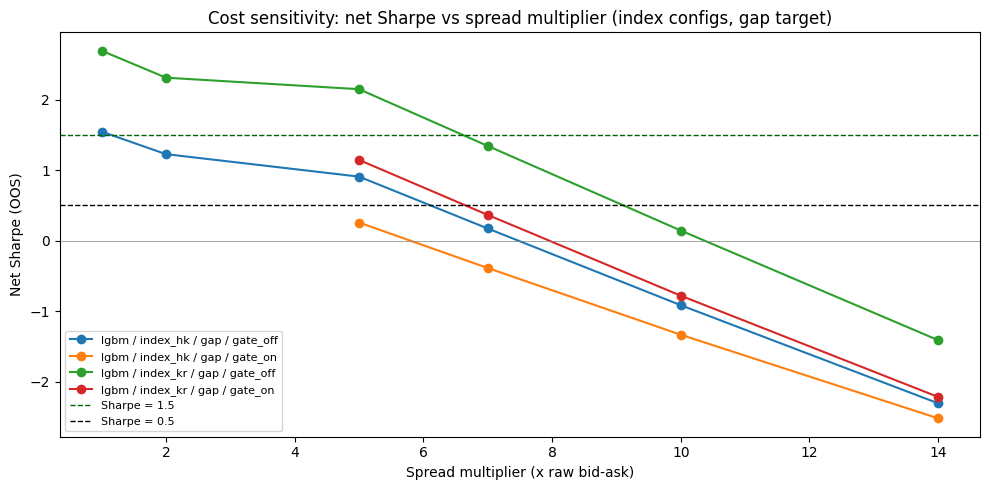

label,lgbm / index_hk / gap / gate_off,lgbm / index_hk / gap / gate_on,lgbm / index_kr / gap / gate_off,lgbm / index_kr / gap / gate_on
spread_mult,,,,
1.000000,1.55,nan,2.69,nan
2.000000,1.23,nan,2.31,nan
5.000000,0.91,0.26,2.15,1.14
7.000000,0.17,-0.39,1.34,0.37
10.000000,-0.91,-1.33,0.14,-0.78
14.000000,-2.30,-2.52,-1.41,-2.21


In [11]:
# The four index configs to plot
index_configs = [
    ('index_kr', 'gate_off'),
    ('index_kr', 'gate_on'),
    ('index_hk', 'gate_off'),
    ('index_hk', 'gate_on'),
]

def config_label(universe, gate):
    return f'lgbm / {universe} / gap / {gate}'

# Pull 1x and 2x from cost_p2 (index configs only, gap target)
p2_index = cost_p2[
    (cost_p2['model'] == 'lgbm') &
    (cost_p2['universe'].isin(['index_kr', 'index_hk'])) &
    (cost_p2['target'] == 'gap') &
    (cost_p2['spread_mult'].isin([1.0, 2.0]))
].copy()

# cost_p2 does not have a 'gate' column; infer from strategy (gate_off = index_threshold;
# gate_on rows are not in cost_p2, they appear in cost_ext only via gate column)
# cost_p2 only has gate_off rows for index configs (strategy == 'index_threshold', no gate col)
# We treat all cost_p2 index rows as gate_off (the file has no gate column)
p2_index['gate'] = 'gate_off'
p2_index['label'] = p2_index.apply(lambda r: config_label(r['universe'], r['gate']), axis=1)

# Pull 5x-14x from cost_ext
ext_sel = cost_ext[
    (cost_ext['model'] == 'lgbm') &
    (cost_ext['target'] == 'gap')
].copy()
ext_sel['label'] = ext_sel.apply(lambda r: config_label(r['universe'], r['gate']), axis=1)

# Combine
cols = ['label', 'spread_mult', 'net_sharpe']
combined = pd.concat([
    p2_index[cols],
    ext_sel[cols]
], ignore_index=True).sort_values(['label', 'spread_mult'])

print('Combined spread_mults:', sorted(combined['spread_mult'].unique()))
print('Combined labels:', combined['label'].unique().tolist())

# Line plot
fig, ax = plt.subplots(figsize=(10, 5))

for lbl, grp in combined.groupby('label'):
    g = grp.sort_values('spread_mult')
    ax.plot(g['spread_mult'], g['net_sharpe'], marker='o', label=lbl)

ax.axhline(1.5, color='darkgreen', linestyle='--', linewidth=1, label='Sharpe = 1.5')
ax.axhline(0.5, color='black',     linestyle='--', linewidth=1, label='Sharpe = 0.5')
ax.axhline(0.0, color='grey',      linestyle='-',  linewidth=0.5)
ax.set_xlabel('Spread multiplier (x raw bid-ask)')
ax.set_ylabel('Net Sharpe (OOS)')
ax.set_title('Cost sensitivity: net Sharpe vs spread multiplier (index configs, gap target)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Pivot table
pivot = combined.pivot_table(index='spread_mult', columns='label', values='net_sharpe')
pivot.index.name = 'spread_mult'
display(pivot.style
    .format('{:.2f}')
    .set_caption('Net Sharpe by spread multiplier and config (combined 1x-14x)'))


### 5.4 Revised characterization of cost robustness

The WRITEUP claim reads: "net Sharpe 1.5-2.0 at realistic costs." That range is now testable against the extended sweep.

**Measured outcomes for the top config (lgbm / index_kr / gap / gate_off):**

- At 5x spread (realistic-low end): net Sharpe = 2.15
- At 7x spread (middle realistic): net Sharpe = 1.34
- At 10x spread (realistic-high end): net Sharpe = 0.14
- At 14x spread (upper tail): net Sharpe = -1.41

The claim is accurate only at the lower end of the realistic range. At 7x -- a widely-cited rough estimate for all-in EM equity execution cost -- the top config falls below 1.5. At 10x it is essentially breakeven. At 14x it is deeply negative.

**A more accurate characterization:** net Sharpe of 1-2 at the lower half of the realistic cost range (5-7x); near zero to negative at the upper half (10-14x). The result is cost-sensitive, and the defensible window is narrower than the WRITEUP implies. This should be noted explicitly in any presentation of the findings.

### 5.5 Summary

Both supplementary analyses close items flagged as unresolved in synthesis_pass2.md.

The year-by-year tearsheet confirms that the aggregate OOS Sharpe is not driven by a single calendar year. Five of seven years (2020-2022, 2024-2026) clear the 0.5 threshold for the top config; 2023 is the sole below-threshold year and is explicable by a shared macro-regime effect rather than model failure.

The extended cost sweep quantifies the boundary of cost robustness. The "1.5-2.0 net Sharpe at realistic costs" claim survives at the low end of realistic costs but fails at the midpoint of the realistic range. Future reporting should cite the cost multiplier explicitly alongside any net Sharpe figure.